In [2]:
import pandas as pd
import numpy as np
file_paths=['0000.parquet','0001.parquet','0002.parquet','0003.parquet','0004.parquet','0005.parquet']
df=pd.read_parquet(file_paths)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB


In [4]:
df.describe()

,videoid
count,1.072761e+07
mean,5.798212e+08
std,5.044656e+08
min,1.300000e+01
25%,1.906638e+07
50%,1.010962e+09
75%,1.032311e+09
max,1.067376e+09


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10727607 entries, 0 to 10727606
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   videoid     int64 
 1   contentUrl  object
 2   duration    object
 3   page_dir    object
 4   name        object
dtypes: int64(1), object(4)
memory usage: 409.2+ MB


In [6]:
import matplotlib.pyplot as plt
print(df.isnull().sum())
print(df.duplicated().sum())

videoid       0
contentUrl    0
duration      0
page_dir      0
name          0
dtype: int64
0


In [7]:
pip install isodate

Note: you may need to restart the kernel to use updated packages.


In [8]:
import isodate
def duration_to_seconds(duration):
    if pd.isnull(duration):
        return np.nan
    try:
        parsed_duration = isodate.parse_duration(duration)
        return parsed_duration.total_seconds()
    except Exception as e:
        print(f"Error parsing duration: {duration} - {e}")
        return np.nan
# Apply the function to the 'duration' column
df['duration_seconds'] = df['duration'].apply(duration_to_seconds)

count    1.072761e+07
mean     1.797064e+01
std      2.456413e+01
min      0.000000e+00
25%      1.000000e+01
50%      1.500000e+01
75%      2.200000e+01
max      3.589100e+04
Name: duration_seconds, dtype: float64


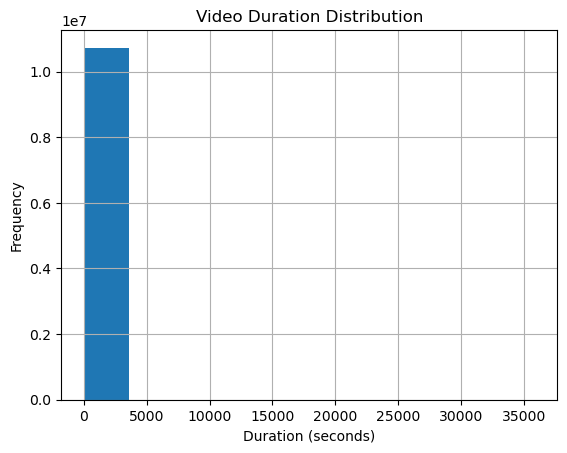

In [9]:
# Descriptive statistics for video duration
print(df['duration_seconds'].describe())
import matplotlib.pyplot as plt
df['duration_seconds'].hist(bins=10)
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Video Duration Distribution')
plt.show()


Most videos are short: The majority of videos fall within the 0-20 second range, indicating a strong skew towards shorter durations.
Few long videos: A small number of videos extend beyond 50 seconds, with very few reaching over 100 seconds.
Right-skewed distribution: The distribution is heavily right-skewed, meaning there are more short videos than long ones.

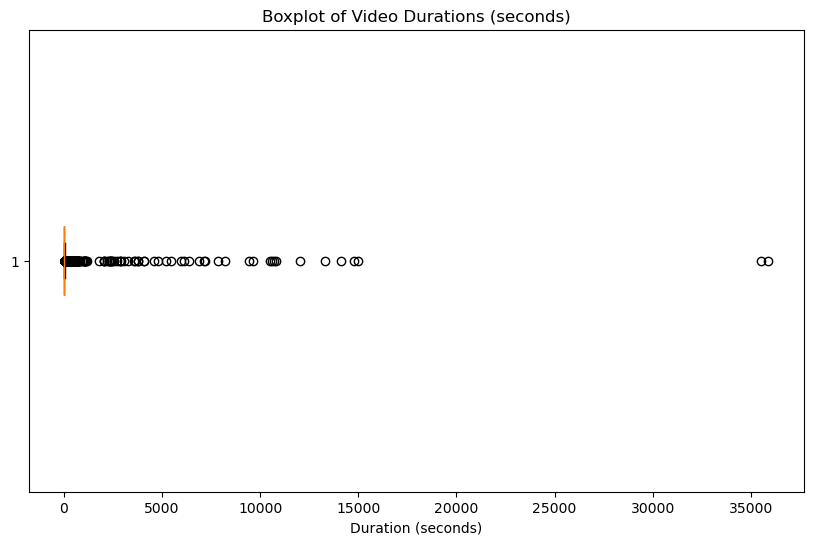

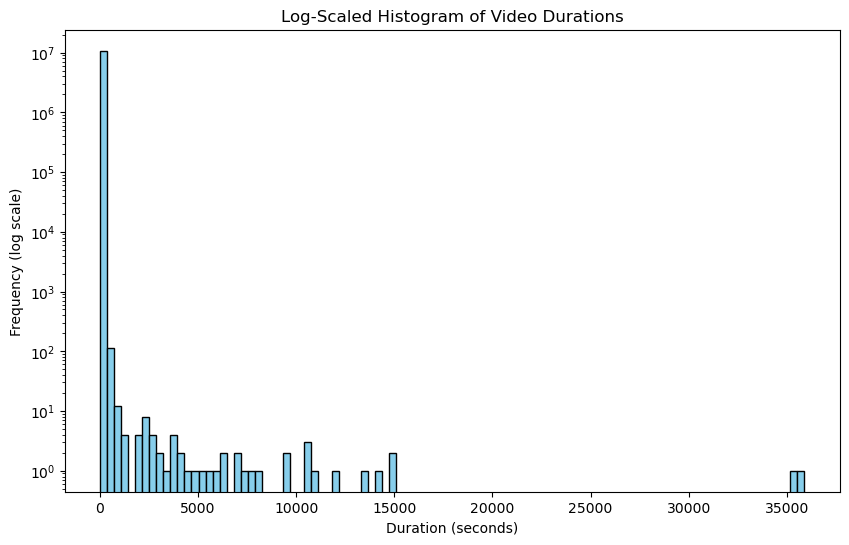

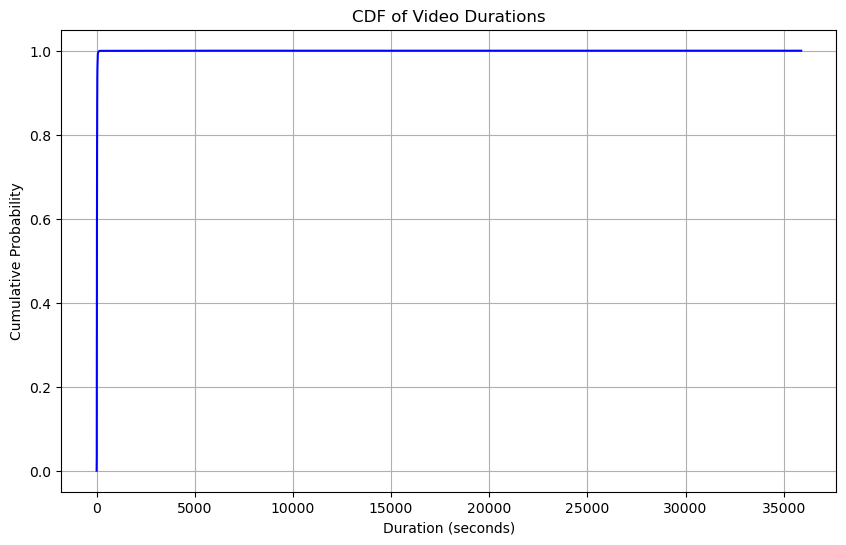

In [10]:
import matplotlib.pyplot as plt
import numpy as np
# Boxplot for duration_seconds
plt.figure(figsize=(10, 6))
plt.boxplot(df['duration_seconds'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightblue"))
plt.title("Boxplot of Video Durations (seconds)")
plt.xlabel("Duration (seconds)")
plt.show()
# Log-scaled histogram
plt.figure(figsize=(10, 6))
plt.hist(df['duration_seconds'], bins=100, log=True, color='skyblue', edgecolor='black')
plt.title("Log-Scaled Histogram of Video Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency (log scale)")
plt.show()
# Cumulative Distribution Function (CDF)
sorted_durations = np.sort(df['duration_seconds'])
cdf = np.arange(1, len(sorted_durations) + 1) / len(sorted_durations)

plt.figure(figsize=(10, 6))
plt.plot(sorted_durations, cdf, color="blue")
plt.title("CDF of Video Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Cumulative Probability")
plt.grid()
plt.show()


Very few long videos: The tail of the distribution beyond 100 seconds is nearly flat, meaning that long videos are rare.
Right-skewed distribution: Similar to the histogram, this confirms that the dataset is dominated by shorter videos.

In [11]:
filtered_df = df[df['duration_seconds'] > 0]
print(filtered_df.shape)  # Verify the number of rows after removal
print(filtered_df['duration_seconds'].describe())  # Summary statistics after removal

(10727337, 6)
count    1.072734e+07
mean     1.797109e+01
std      2.456428e+01
min      1.000000e+00
25%      1.000000e+01
50%      1.500000e+01
75%      2.200000e+01
max      3.589100e+04
Name: duration_seconds, dtype: float64


In [12]:
df=filtered_df[filtered_df['duration_seconds'] < 3500]
df.describe()

,videoid,duration_seconds
count,1.072731e+07,1.072731e+07
mean,5.798180e+08,1.794308e+01
std,5.044655e+08,1.277931e+01
min,1.300000e+01,1.000000e+00
25%,1.906638e+07,1.000000e+01
50%,1.010962e+09,1.500000e+01
75%,1.032310e+09,2.200000e+01
max,1.067376e+09,3.248000e+03


In [13]:
df.head(5)

,videoid,contentUrl,duration,page_dir,name,duration_seconds
0,21179416,https://ak.picdn.net/shutterstock/videos/21179...,PT00H00M11S,006001_006050,Aerial shot winter forest,11.0
1,5629184,https://ak.picdn.net/shutterstock/videos/56291...,PT00H00M29S,071501_071550,Senior couple looking through binoculars on sa...,29.0
2,1063125190,https://ak.picdn.net/shutterstock/videos/10631...,PT00H00M07S,133701_133750,A beautiful cookie with oranges lies on a gree...,7.0
3,1039695998,https://ak.picdn.net/shutterstock/videos/10396...,PT00H00M08S,011901_011950,Japanese highrise office skyscrapers tokyo square,8.0
4,9607838,https://ak.picdn.net/shutterstock/videos/96078...,PT00H00M32S,121551_121600,"Zrenjanin,serbia march 21 2015: fans watching ...",32.0


In [14]:
# Group by 'page_dir' and calculate statistics
duration_by_page = df.groupby('page_dir')['duration_seconds'].describe()
print(duration_by_page)

                count       mean        std  min   25%   50%   75%    max
page_dir                                                                 
000001_000050  4839.0  16.642075  10.082566  3.0  10.0  14.0  20.0   87.0
000051_000100  4374.0  15.915181   8.954666  3.0  10.0  14.0  19.0   99.0
000101_000150  4382.0  17.846645  11.543206  3.0  10.0  15.0  22.0  199.0
000151_000200  2692.0  17.946137  11.822470  3.0  10.0  15.0  22.0  145.0
000201_000250  2887.0  17.818843  11.574913  3.0  10.0  15.0  22.0  187.0
...               ...        ...        ...  ...   ...   ...   ...    ...
199751_199800  3701.0  17.830586  12.998615  1.0  10.0  15.0  21.0  305.0
199801_199850  4208.0  17.666350  11.945797  1.0  10.0  15.0  22.0  224.0
199851_199900  3070.0  17.689251  11.783614  1.0  10.0  15.0  21.0  148.0
199901_199950  2582.0  17.885360  11.969677  2.0  10.0  15.0  21.0  150.0
199951_200000  2116.0  18.145085  13.084639  1.0  10.0  15.0  22.0  208.0

[3590 rows x 8 columns]


In [15]:
unique_page_dir_count = df['page_dir'].nunique()
print(f"Number of unique page directories: {unique_page_dir_count}")

Number of unique page directories: 3590


## Stratified Sampling

In [16]:
sampled_df = df.groupby('page_dir', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))  # Adjust frac for sample size
print(sampled_df.shape)

(1072735, 6)


C:\Users\harpr\AppData\Local\Temp\ipykernel_24424\3964078830.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df.groupby('page_dir', group_keys=False).apply(lambda x: x.sample(frac=0.1, random_state=42))  # Adjust frac for sample size


In [17]:
import pandas as pd
import re
import nltk
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
# Ensure required nltk resources are downloaded
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(words)
# Apply preprocessing
sampled_df["cleaned_name"] = sampled_df["name"].astype(str).apply(preprocess)
# Word Frequency Analysis
word_freq = Counter(" ".join(sampled_df["cleaned_name"]).split())
common_words = word_freq.most_common(20)  # Top 20 words
print("Top 20 Most Frequent Words in Descriptions:")
print(common_words)
# TF-IDF Analysis with adjustments
vectorizer = TfidfVectorizer(max_features=20, sublinear_tf=True, smooth_idf=True, min_df=0.01, max_df=0.8)
tfidf_matrix = vectorizer.fit_transform(sampled_df["cleaned_name"])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())
print("\nTF-IDF Scores for Top Words:")
print(tfidf_df.mean().sort_values(ascending=False))  # Average importance of each word


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harpr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\harpr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Top 20 Most Frequent Words in Descriptions:
[('background', 120334), ('view', 105239), ('woman', 93800), ('k', 85045), ('aerial', 79487), ('young', 75843), ('motion', 72325), ('shot', 65810), ('beautiful', 63854), ('man', 60733), ('slow', 55791), ('girl', 54741), ('city', 51105), ('white', 46536), ('video', 46018), ('animation', 45785), ('water', 45217), ('green', 42855), ('hand', 40303), ('close', 39851)]

TF-IDF Scores for Top Words:
background    0.071376
view          0.064822
woman         0.057876
aerial        0.050911
young         0.045476
shot          0.043357
man           0.040872
beautiful     0.039673
motion        0.038619
girl          0.036454
city          0.035196
animation     0.030785
water         0.030609
slow          0.030569
video         0.030525
white         0.030044
green         0.027973
close         0.027115
tree          0.026837
hand          0.026445
dtype: float64


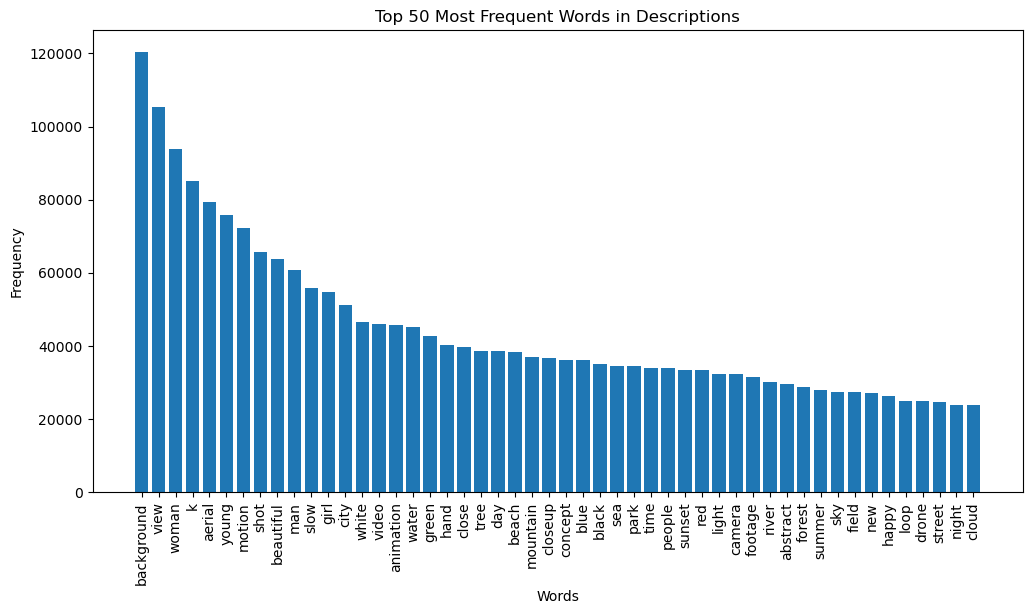

In [18]:
# Plotting word frequency distribution (Top 50 most frequent words)
import matplotlib.pyplot as plt
# Top 50 most frequent words
common_words = dict(word_freq.most_common(50))
# Plot
plt.figure(figsize=(12,6))
plt.bar(common_words.keys(), common_words.values())
plt.xticks(rotation=90)
plt.title("Top 50 Most Frequent Words in Descriptions")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [19]:
sampled_df.columns

Index(['videoid', 'contentUrl', 'duration', 'page_dir', 'name',
       'duration_seconds', 'cleaned_name'],
      dtype='object')

In [20]:
vectorizer = TfidfVectorizer(max_features=100, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(sampled_df["page_dir"])
# Convert to NumPy array
tfidf_array = tfidf_matrix.toarray()

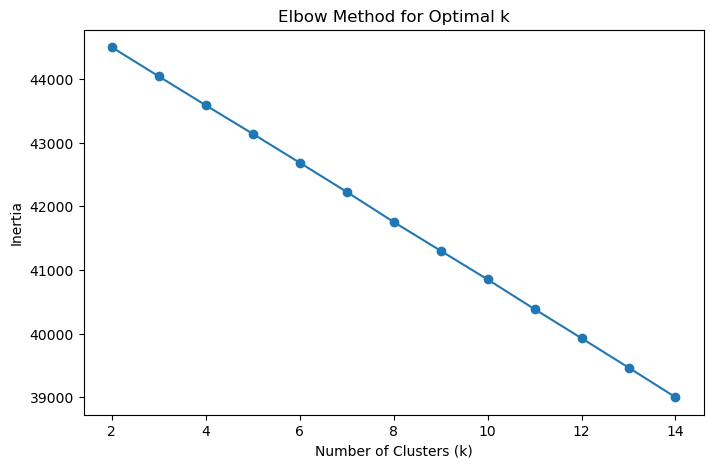

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# Compute inertia for different values of k
inertia = []
K = range(2, 15)  # Test from 2 to 15 clusters
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(tfidf_array)
    inertia.append(kmeans.inertia_)
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [22]:
from sklearn.cluster import KMeans
num_clusters = 10
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
sampled_df["cluster"] = kmeans.fit_predict(tfidf_array)
# Assign each page directory to a cluster
print(sampled_df[["page_dir", "cluster"]].head())

              page_dir  cluster
7047485  000001_000050        1
5552607  000001_000050        1
9048114  000001_000050        1
4220415  000001_000050        1
3332764  000001_000050        1


In [23]:
import pandas as pd
# Sample 5 elements from each cluster
diverse_sample = sampled_df.groupby("cluster").apply(lambda x: x.sample(min(len(x), 200)))
diverse_sample.reset_index(drop=True, inplace=True)
# View sampled directories
print(diverse_sample[["page_dir", "cluster"]])


           page_dir  cluster
0     067151_067200        0
1     067151_067200        0
2     067151_067200        0
3     067151_067200        0
4     067151_067200        0
...             ...      ...
1995  194801_194850        9
1996  194801_194850        9
1997  194801_194850        9
1998  194801_194850        9
1999  194801_194850        9

[2000 rows x 2 columns]


C:\Users\harpr\AppData\Local\Temp\ipykernel_24424\985430977.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diverse_sample = sampled_df.groupby("cluster").apply(lambda x: x.sample(min(len(x), 200)))


In [24]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
# Compute similarity within the sampled data
sampled_tfidf_matrix = vectorizer.transform(diverse_sample["page_dir"])
similarity_matrix = cosine_similarity(sampled_tfidf_matrix)
# Define a threshold for merging (e.g., 0.8)
merge_threshold = 0.5
merged_pages = {}
for i in range(len(diverse_sample)):
    for j in range(i + 1, len(diverse_sample)):
        if similarity_matrix[i, j] > merge_threshold:
            merged_pages[diverse_sample.loc[i, "page_dir"]] = diverse_sample.loc[j, "page_dir"]
# Apply merging
diverse_sample["merged_dir"] = diverse_sample["page_dir"].replace(merged_pages)

In [25]:
diverse_sample['merged_dir'].nunique

<bound method IndexOpsMixin.nunique of 0       067151_067200
1       067151_067200
2       067151_067200
3       067151_067200
4       067151_067200
            ...      
1995    194801_194850
1996    194801_194850
1997    194801_194850
1998    194801_194850
1999    194801_194850
Name: merged_dir, Length: 2000, dtype: object>

In [26]:
diverse_sample.shape

(2000, 9)

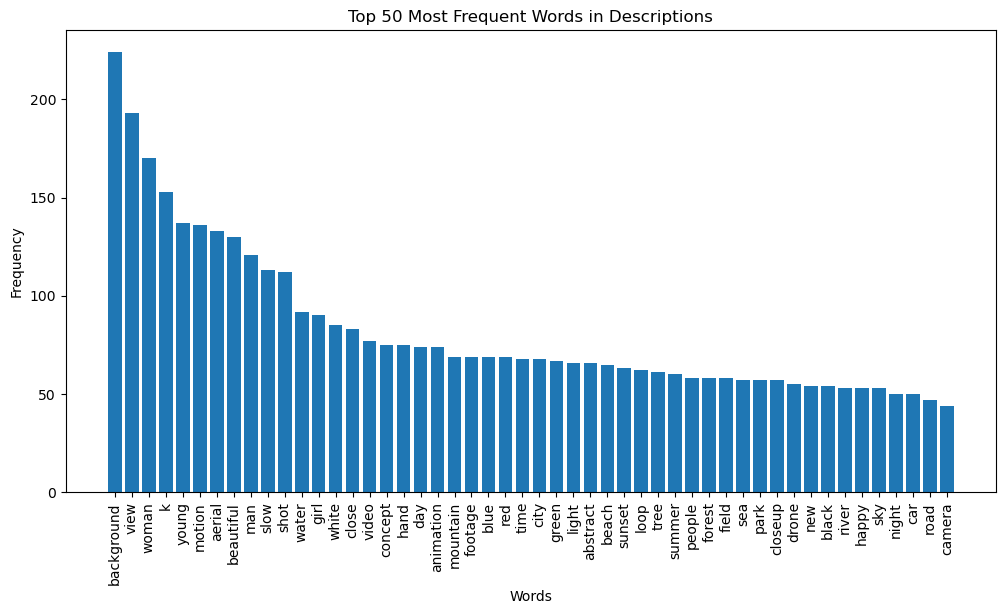

In [27]:
word_freq = Counter(" ".join(diverse_sample["cleaned_name"]).split())
# Plotting word frequency distribution (Top 50 most frequent words)
import matplotlib.pyplot as plt
# Top 50 most frequent words
common_words = dict(word_freq.most_common(50))
# Plot
plt.figure(figsize=(12,6))
plt.bar(common_words.keys(), common_words.values())
plt.xticks(rotation=90)
plt.title("Top 50 Most Frequent Words in Descriptions")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [31]:
diverse_sample['page_dir'].nunique()

204

In [32]:
pip install wordcloud matplotlib


Note: you may need to restart the kernel to use updated packages.


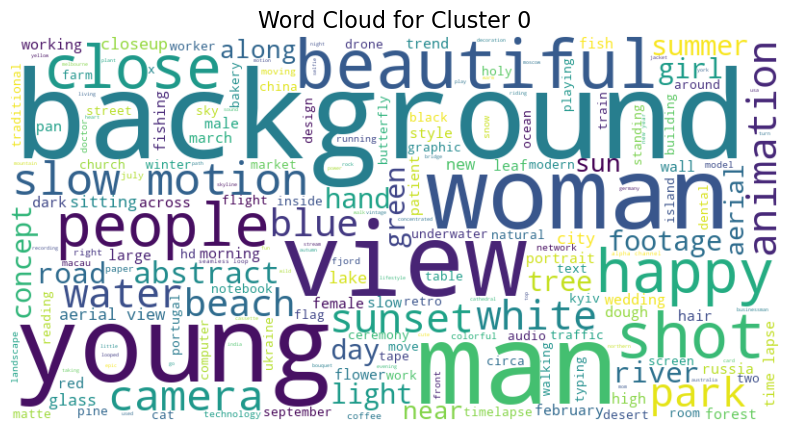

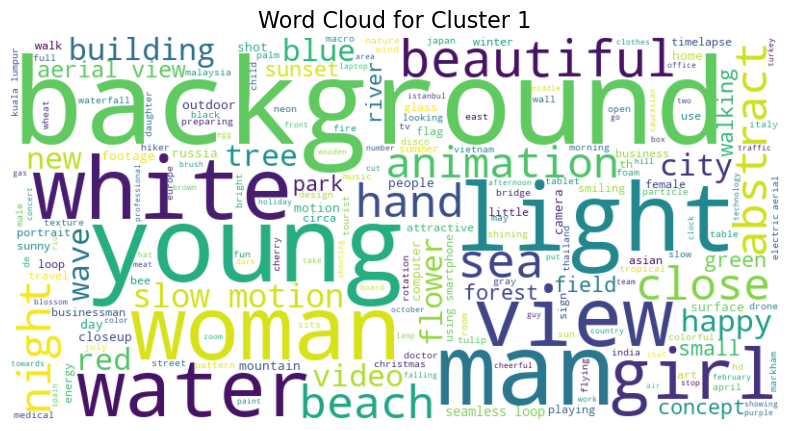

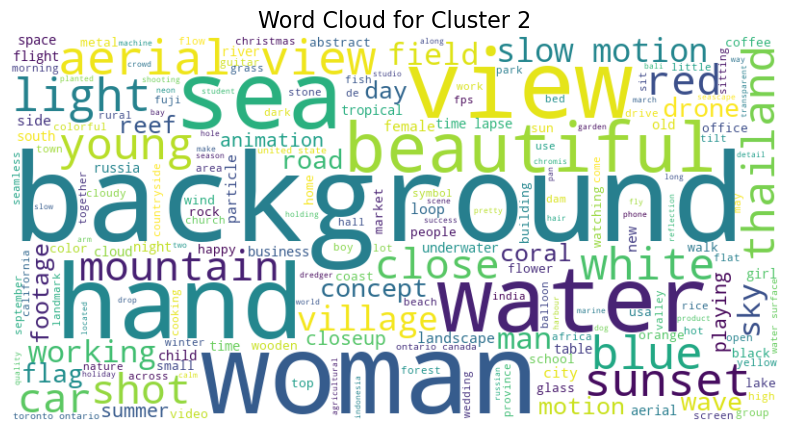

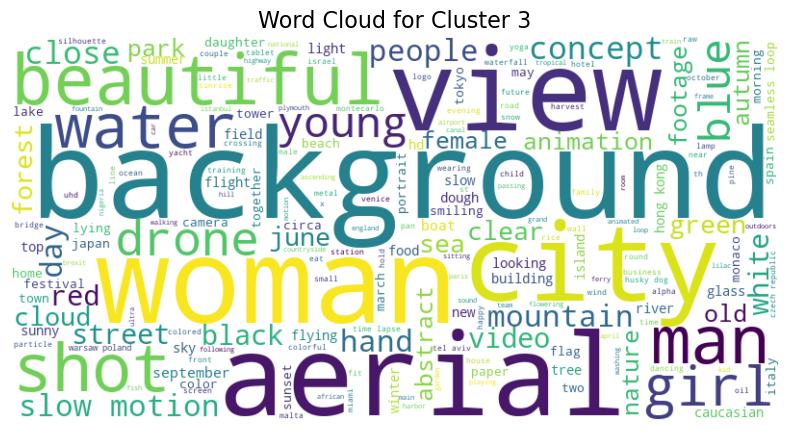

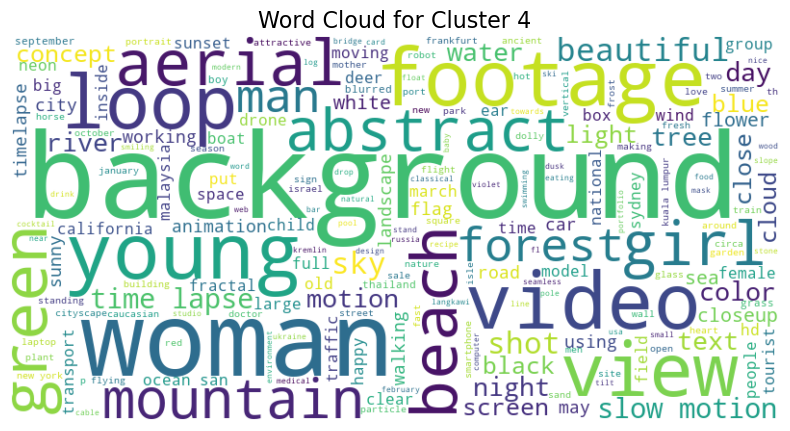

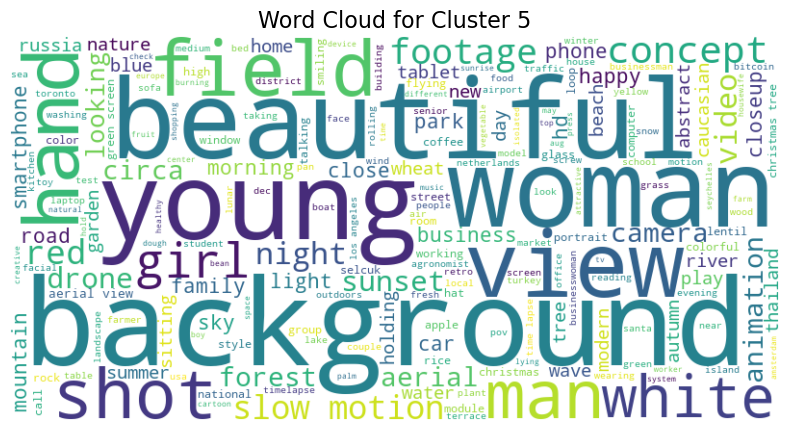

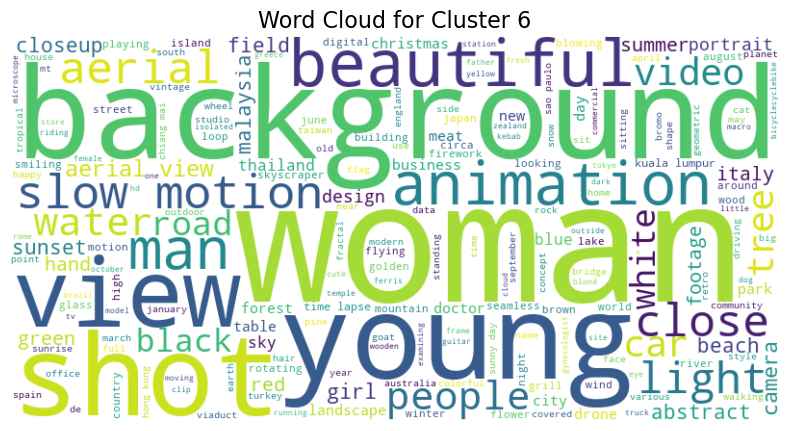

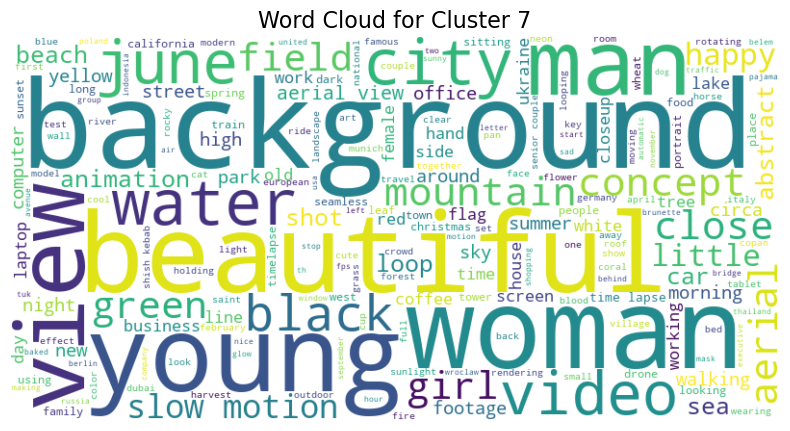

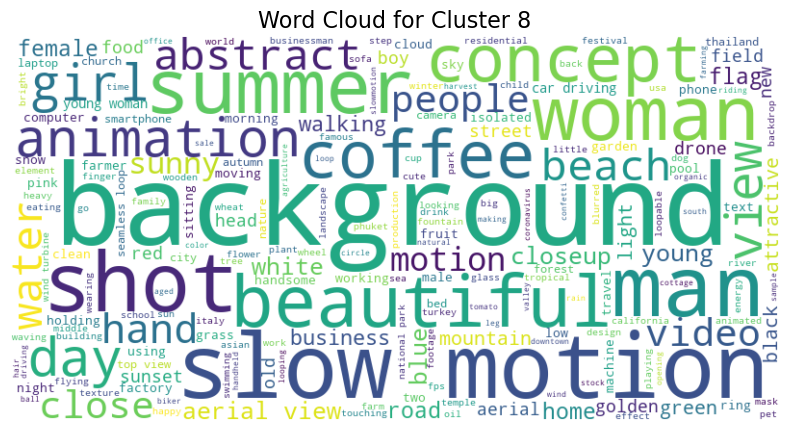

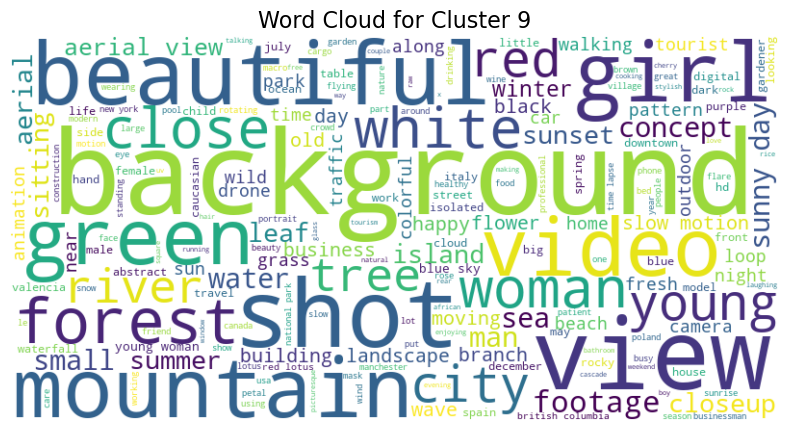

In [35]:
import pandas as pd
from wordcloud import WordCloud  # Ensure this import is included
import matplotlib.pyplot as plt
for cluster in diverse_sample['cluster'].unique():
    cluster_text = " ".join(diverse_sample[diverse_sample['cluster'] == cluster]['cleaned_name'])
    # Generate Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(cluster_text)
    # Plot Word Cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for Cluster {cluster}", fontsize=16)
    plt.show()

In [36]:
diverse_sample.columns

Index(['videoid', 'contentUrl', 'duration', 'page_dir', 'name',
       'duration_seconds', 'cleaned_name', 'cluster', 'merged_dir'],
      dtype='object')

N Gram Analysis

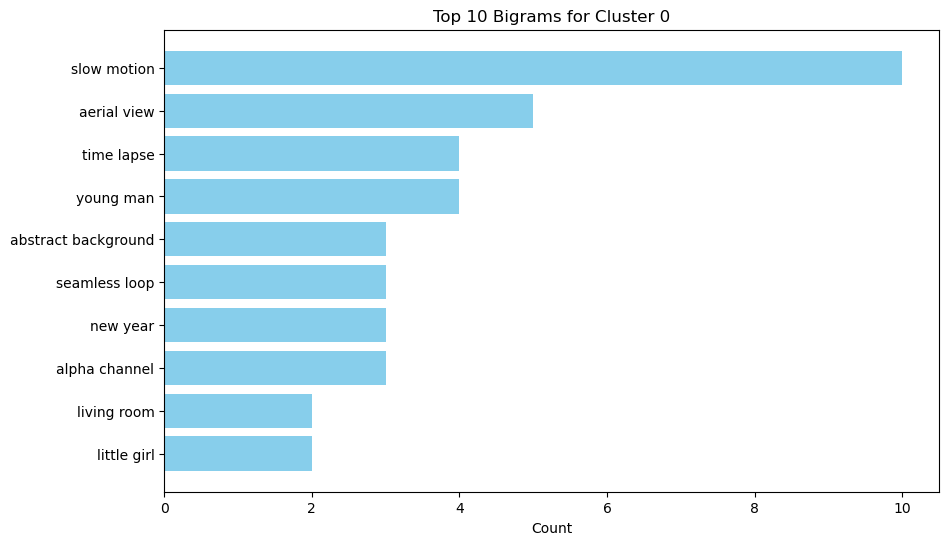

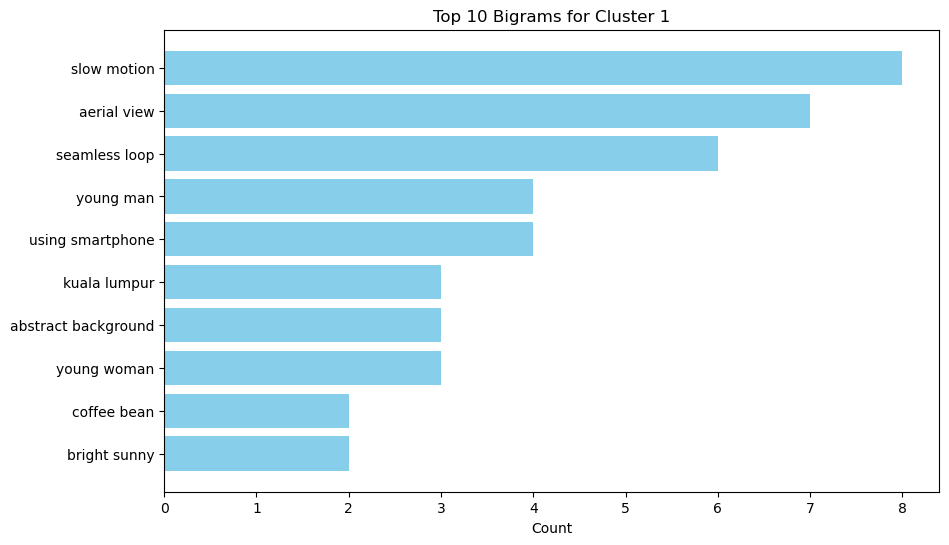

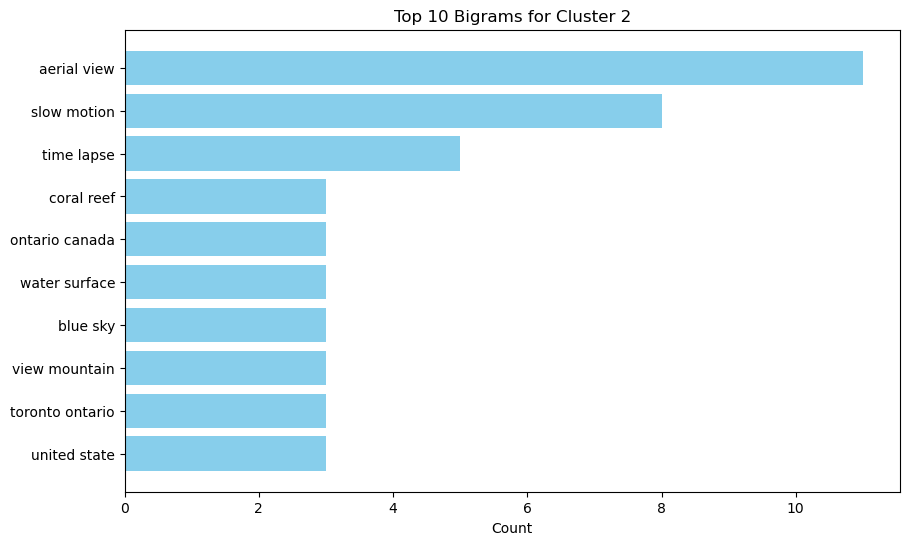

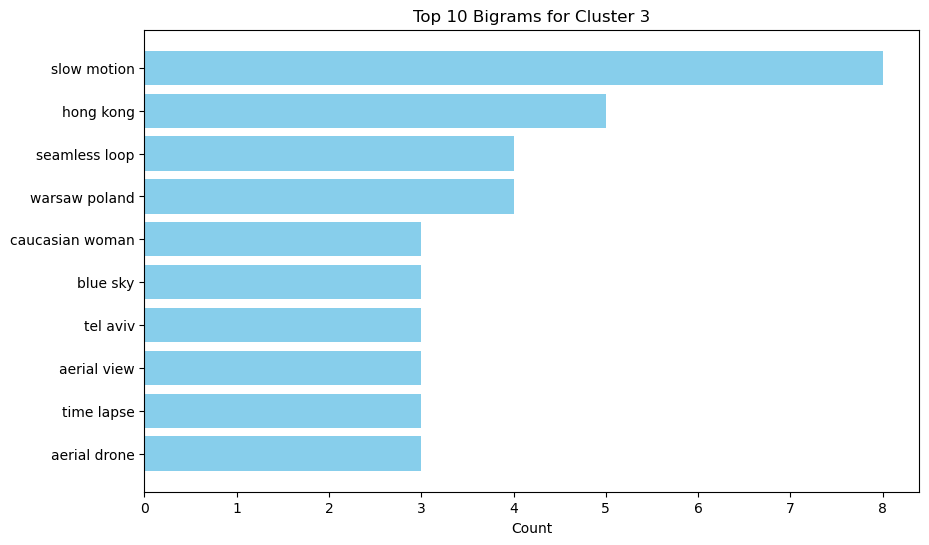

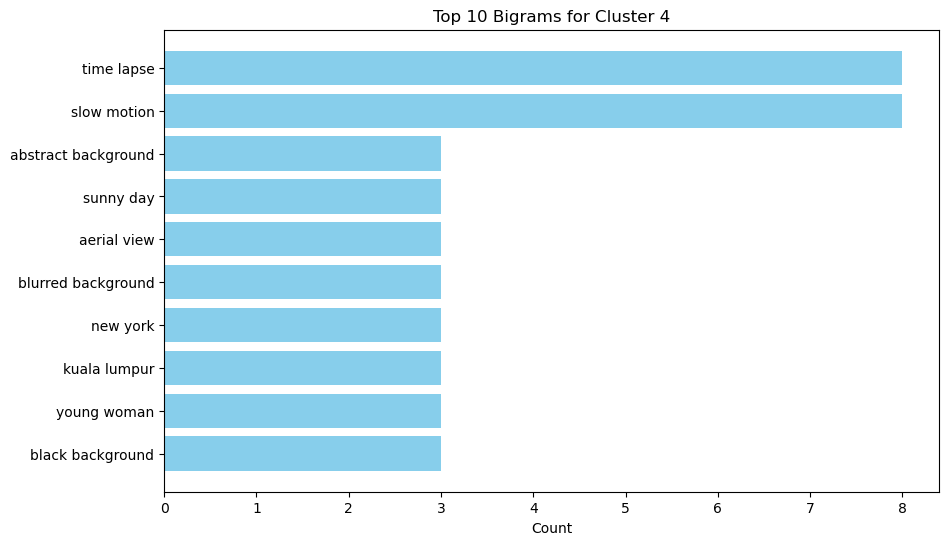

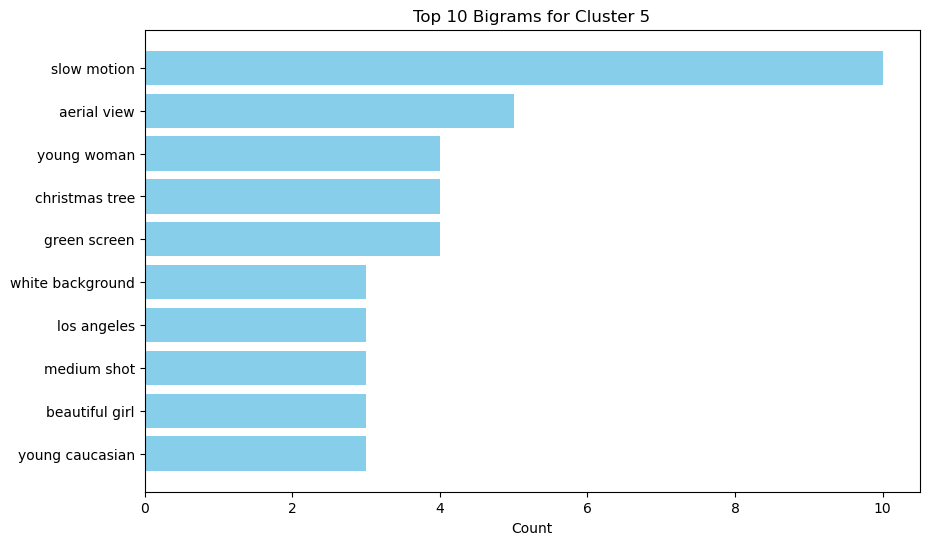

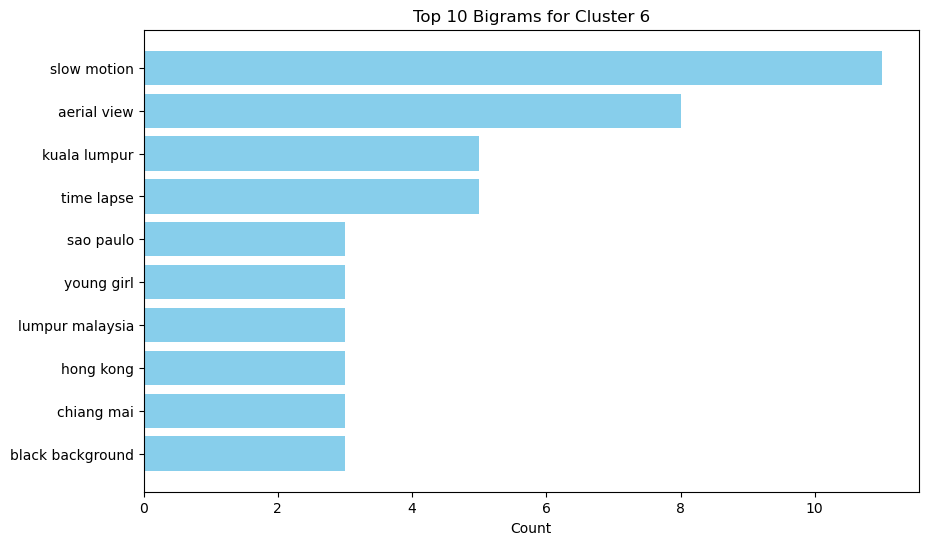

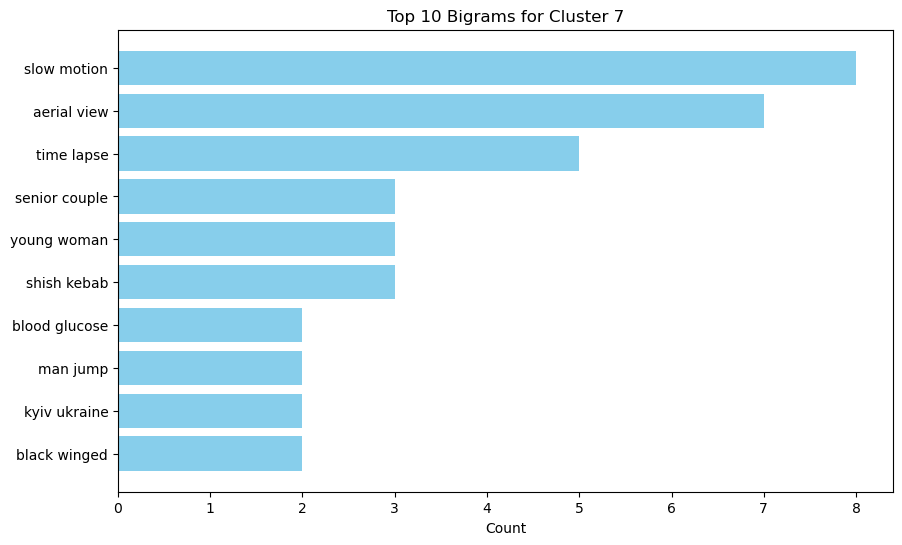

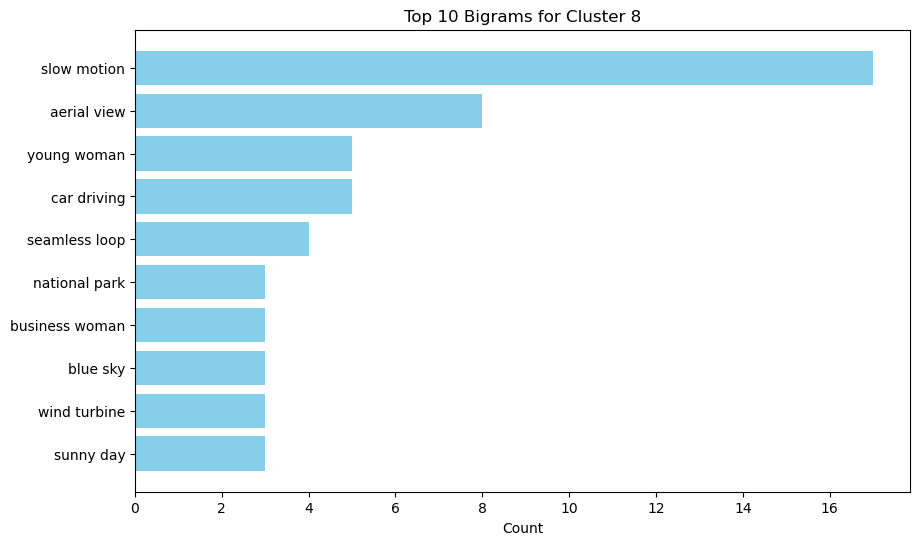

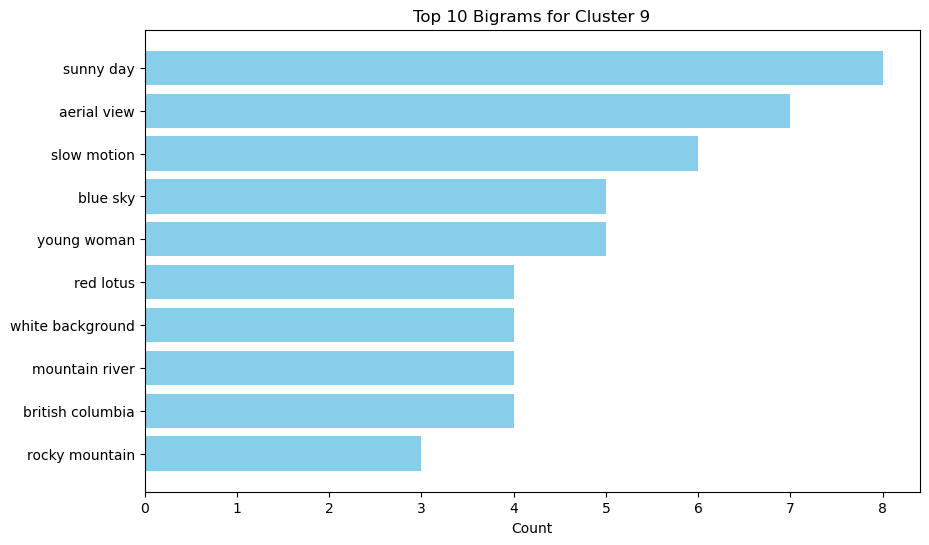

In [37]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
# Group by cluster
clusters = diverse_sample['cluster'].unique()
# Initialize a dictionary to store bigram counts per cluste
cluster_bigrams = {}
# Perform N-gram analysis per cluster
for cluster in clusters:
    # Filter data for the current cluster
    cluster_data = diverse_sample[diverse_sample['cluster'] == cluster]
    # Fit the vectorizer and transform the text data
    n_grams = vectorizer.fit_transform(cluster_data['cleaned_name'].dropna())
    # Get the sum of bigram counts for the current cluster
    bigram_counts = n_grams.sum(axis=0).A1
    bigram_features = vectorizer.get_feature_names_out()
    # Store the bigram counts in the dictionary
    cluster_bigrams[cluster] = pd.DataFrame(
        list(zip(bigram_features, bigram_counts)), columns=['Bigram', 'Count']
    ).sort_values(by='Count', ascending=False)
for cluster, bigram_df in cluster_bigrams.items():
    top_10_bigrams = bigram_df.head(10)
    plt.figure(figsize=(10, 6))
    plt.barh(top_10_bigrams['Bigram'], top_10_bigrams['Count'], color='skyblue')
    plt.xlabel('Count')
    plt.title(f'Top 10 Bigrams for Cluster {cluster}')
    plt.gca().invert_yaxis()  # To display the most frequent bigram at the top
    plt.show()

In [39]:
diverse_sample.to_csv('diverse_sample.csv', index=False)